In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [122]:
# Set the folder path where your CSV files are located
folder_path = r'C:\Users\demymelgar\Documents\DATA_Labs\Capstone_2'

# Load all 5 CSV files
store_detail = pd.read_csv(folder_path + r'\StoreDetail.csv')
store_sales = pd.read_csv(folder_path + r'\StoreSales.csv')
products = pd.read_csv(folder_path + r'\Products.csv')
product_categories = pd.read_csv(folder_path + r'\ProductCategories.csv')
customer_list = pd.read_csv(folder_path + r'\customer_list.csv', sep='|')

print("All data loaded successfully!")

All data loaded successfully!


## Question 1: Who are the territory managers? What are the store IDs and cities for each territory?

In [123]:
# Filter for Maine and Massachusetts stores
my_stores = store_detail[store_detail['State'].isin(['Maine', 'Massachusetts'])]

# Show the full table
print(my_stores[['State', 'Territory Manager', 'Store ID', 'Store Location']].to_string(index=False))

# Summary by territory
print("\n" + "=" * 50)
print("TERRITORY SUMMARY")
print("=" * 50)

for state in ['Maine', 'Massachusetts']:
    stores_in_state = my_stores[my_stores['State'] == state]
    manager = stores_in_state['Territory Manager'].iloc[0]
    num_stores = len(stores_in_state)
    cities = ', '.join(stores_in_state['Store Location'].tolist())
    
    print(f"\n {state}")
    print(f"   Territory Manager: {manager}")
    print(f"   Number of Stores: {num_stores}")
    print(f"   Cities: {cities}")


        State Territory Manager  Store ID Store Location
        Maine Erbayne Middleton       818         Bangor
        Maine Erbayne Middleton       819     Bar Harbor
        Maine Erbayne Middleton       820  Kennebunkport
        Maine Erbayne Middleton       821       Lewiston
        Maine Erbayne Middleton       822          Orono
        Maine Erbayne Middleton       823 South Portland
Massachusetts           Bo Heap       730         Boston
Massachusetts           Bo Heap       801      Attleboro
Massachusetts           Bo Heap       802       Falmouth
Massachusetts           Bo Heap       803     Framingham
Massachusetts           Bo Heap       804      Haverhill
Massachusetts           Bo Heap       805        Hingham
Massachusetts           Bo Heap       806        Holyoke
Massachusetts           Bo Heap       807     Leominster
Massachusetts           Bo Heap       808         Lowell
Massachusetts           Bo Heap       809           Lynn
Massachusetts           Bo Heap

## Question 2: Monthly Total Revenue by Territory

In [124]:
# Make sure Transaction Date is datetime (in case we skipped cleaning)
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Merge sales with store info
sales_with_stores = store_sales.merge(store_detail, on='Store ID')

# Filter for Maine and Massachusetts
my_sales = sales_with_stores[sales_with_stores['State'].isin(['Maine', 'Massachusetts'])].copy()

# Create a Month column (formatted as YYYY-MM)
my_sales['Month'] = my_sales['Transaction Date'].dt.to_period('M')

# Group by state and month
monthly_revenue = my_sales.groupby(['State', 'Month'])['Sale Amount'].sum().reset_index()
monthly_revenue['Sale Amount'] = monthly_revenue['Sale Amount'].round(2)

# Show results
print("MONTHLY REVENUE - MAINE:")
print(monthly_revenue[monthly_revenue['State'] == 'Maine'])

print("\nMONTHLY REVENUE - MASSACHUSETTS:")
print(monthly_revenue[monthly_revenue['State'] == 'Massachusetts'])


MONTHLY REVENUE - MAINE:
    State    Month  Sale Amount
0   Maine  2022-01     15700.31
1   Maine  2022-02     21008.29
2   Maine  2022-03     23173.23
3   Maine  2022-04     20169.19
4   Maine  2022-05     22631.11
5   Maine  2022-06     31573.93
6   Maine  2022-07     19371.11
7   Maine  2022-08     27979.07
8   Maine  2022-09     27393.30
9   Maine  2022-10     24947.09
10  Maine  2022-11     19783.08
11  Maine  2022-12     25345.23
12  Maine  2023-01     41331.95
13  Maine  2023-02     37650.30
14  Maine  2023-03     36162.92
15  Maine  2023-04     35875.41
16  Maine  2023-05     26201.22
17  Maine  2023-06     30183.66
18  Maine  2023-07     44731.17
19  Maine  2023-08     42202.08
20  Maine  2023-09     44862.59
21  Maine  2023-10     34905.29
22  Maine  2023-11     35428.88
23  Maine  2023-12     41279.32
24  Maine  2024-01     43881.68
25  Maine  2024-02     31494.48
26  Maine  2024-03     36311.69
27  Maine  2024-04     25764.94
28  Maine  2024-05     31426.20
29  Maine  2024

# Question 3: Rank stores by performance in each territory

In [125]:
store_ranking = my_sales.groupby(
    ['State', 'Store Location', 'Store ID']
)['Sale Amount'].sum().reset_index()

store_ranking['Sale Amount'] = store_ranking['Sale Amount'].round(2)

# Sort by state, then by revenue (highest first)
store_ranking = store_ranking.sort_values(['State', 'Sale Amount'], ascending=[True, False])

# Add a rank within each state
store_ranking['Rank'] = store_ranking.groupby('State')['Sale Amount'].rank(ascending=False).astype(int)

# Show Maine ranking
print("MAINE STORE RANKING:")
print(store_ranking[store_ranking['State'] == 'Maine'][['Rank', 'Store Location', 'Store ID', 'Sale Amount']].to_string(index=False))

# Show Massachusetts ranking
print("\nMASSACHUSETTS STORE RANKING:")
print(store_ranking[store_ranking['State'] == 'Massachusetts'][['Rank', 'Store Location', 'Store ID', 'Sale Amount']].to_string(index=False))


MAINE STORE RANKING:
 Rank Store Location  Store ID  Sale Amount
    1 South Portland       823    332611.76
    2          Orono       822    330505.47
    3  Kennebunkport       820    321998.55
    4       Lewiston       821    303761.91
    5         Bangor       818    300919.98
    6     Bar Harbor       819    287452.08

MASSACHUSETTS STORE RANKING:
 Rank Store Location  Store ID  Sale Amount
    1      Worcester       817    602183.44
    2     Leominster       807    338009.10
    3      Nantucket       810    335547.81
    4   Provincetown       814    328860.51
    5    Northampton       812    322039.24
    6        Holyoke       806    320516.53
    7     Somerville       816    312873.59
    8      Haverhill       804    305762.60
    9           Lynn       809    302049.65
   10     Pittsfield       813    301281.50
   11    New Bedford       811    295443.42
   12         Boston       730    295201.29
   13      Attleboro       801    290883.71
   14        Hingham     

# Question 4: Top customers in each sales territory

In [126]:
customer_list = pd.read_csv(folder_path + r'\customer_list.csv', sep='|')

# Keep only sales with a RewardsID
sales_with_rewards = my_sales.dropna(subset=['RewardsID']).copy()
sales_with_rewards['RewardsID'] = sales_with_rewards['RewardsID'].astype(int)

# Merge sales with customer names
merged = sales_with_rewards.merge(customer_list, left_on='RewardsID', right_on='cust_id')

# Top 5 customers per state
top_customers = merged.groupby(['State', 'name'])['Sale Amount'].sum().reset_index()

print("TOP 5 CUSTOMERS - MAINE:")
print(top_customers[top_customers['State'] == 'Maine'].sort_values('Sale Amount', ascending=False).head(5).to_string(index=False))

print("\nTOP 5 CUSTOMERS - MASSACHUSETTS:")
print(top_customers[top_customers['State'] == 'Massachusetts'].sort_values('Sale Amount', ascending=False).head(5).to_string(index=False))


TOP 5 CUSTOMERS - MAINE:
State         name  Sale Amount
Maine       Rosita      3637.75
Maine Karen Walker      3362.83
Maine  Maddy Perez      2706.42
Maine      Mike H.      2695.22
Maine Philip Banks      2662.84

TOP 5 CUSTOMERS - MASSACHUSETTS:
        State            name  Sale Amount
Massachusetts Beverly Crusher      4758.92
Massachusetts    Tracy Jordan      4197.55
Massachusetts   Jesse Pinkman      4170.75
Massachusetts      Stanley H.      3979.73
Massachusetts   Monica Geller      3966.91


# Question 5: Transactions per month and revenue per month by category

In [127]:

# Merge sales with products to get CategoryID
sales_with_products = my_sales.merge(products, on='Prod Num')

# Get unique categories (since ProductCategories.csv has duplicates per subcategory)
categories = product_categories[['CategoryID', 'Category']].drop_duplicates()

# Merge to get category names
full_data = sales_with_products.merge(categories, on='CategoryID')

# Create Month column
full_data['Month'] = full_data['Transaction Date'].dt.to_period('M')

# Group by state, month, and category
category_analysis = full_data.groupby(['State', 'Month', 'Category']).agg(
    NumTransactions=('Sale Amount', 'count'),
    TotalRevenue=('Sale Amount', 'sum')
).reset_index()

category_analysis['TotalRevenue'] = category_analysis['TotalRevenue'].round(2)

# Show first 20 rows for each state
print("CATEGORY ANALYSIS - MAINE (first 20 rows):")
print(category_analysis[category_analysis['State'] == 'Maine'].head(20).to_string(index=False))

print("\nCATEGORY ANALYSIS - MASSACHUSETTS (first 20 rows):")
print(category_analysis[category_analysis['State'] == 'Massachusetts'].head(20).to_string(index=False))

CATEGORY ANALYSIS - MAINE (first 20 rows):
State   Month                 Category  NumTransactions  TotalRevenue
Maine 2022-01  Apparel and Merchandise               30        958.97
Maine 2022-01             Art Supplies               31        857.61
Maine 2022-01          Books (General)               12        370.52
Maine 2022-01  Stationery and Supplies               29        232.05
Maine 2022-01 Technology & Accessories               35       9007.64
Maine 2022-01                Textbooks               24       4273.52
Maine 2022-02  Apparel and Merchandise               22        767.63
Maine 2022-02             Art Supplies               27        776.61
Maine 2022-02          Books (General)               14        294.65
Maine 2022-02  Stationery and Supplies               23        218.02
Maine 2022-02 Technology & Accessories               35      15341.85
Maine 2022-02                Textbooks               22       3609.53
Maine 2022-03  Apparel and Merchandise         

### Analysis part of Question 5: 
-This information tells me about the most popular products,that in Massachusetts, Technology & Accessories have the highest transaction amounts (112 in Jan 2022) Another high count is *Stationery & Supplies* which in contrast has a low-revenue.I can gauge from this information that theres high demand for stationery items but the Tech & Accessories category showcases the real revenue.

    **Growth Opportunity**
-In Maine, the tech sales are lower than Massachusetts, the comparison being $9,000 **verses** $48,000 per month therefore, room for growth is in Maine for tech sales.Two stores that are not performing that well are, Lowell, Massachusetts and Bar Harbor, Maine. Focusing on these two stores to raise revenue especially in the Tech & Accessories. I could recommend creating a promo deal, including the Stationery category and Tech category to optimize sales.

## Question 6: Recommendation for next Quarter

My recommendation is to putting the focus on Technology & Accessories specifically in both Lowell, Massachusetts and Bar Harbor, Maine. Both of these stores had the lowest performance in terms of revenue which highlights a need for growth. Technology & Accessories has showcased the highest revenue out of all categories. Knowing this, I would put an emphasis on Technology & Accessories and create a promo deal linked with other categories such as Stationery to drive sales up. Also can offer a reward program for the Tech category to keep customers returning to these stores. Overall, in terms of Tech sales, Maine is significantly lower than Massachusetts. This is also a big area to focusing on for growth to close that gap between them in sales.

# Chart for Monthly Revenue Trend (question 2)

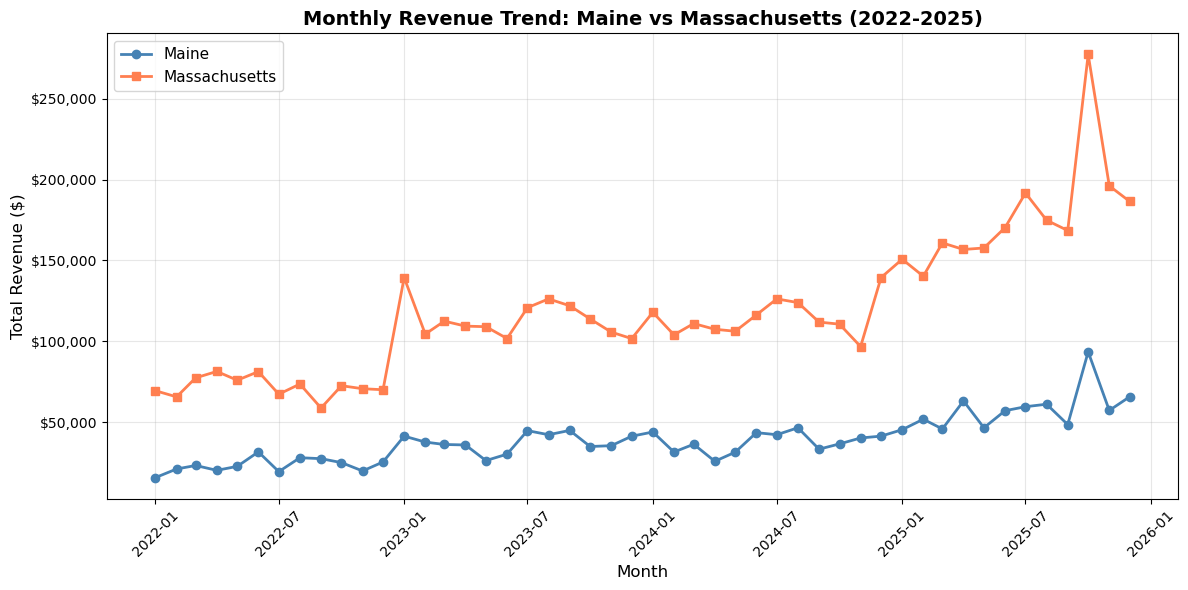

In [128]:
import matplotlib.pyplot as plt

# Prepare data - convert Month period back to timestamp for plotting
plot_data = monthly_revenue.copy()
plot_data['Month'] = plot_data['Month'].dt.to_timestamp()

# Separate the two states
maine_data = plot_data[plot_data['State'] == 'Maine']
mass_data = plot_data[plot_data['State'] == 'Massachusetts']

# Create the line chart
plt.figure(figsize=(12, 6))
plt.plot(maine_data['Month'], maine_data['Sale Amount'], marker='o', label='Maine', color='steelblue', linewidth=2)
plt.plot(mass_data['Month'], mass_data['Sale Amount'], marker='s', label='Massachusetts', color='coral', linewidth=2)

# Labels and title
plt.title('Monthly Revenue Trend: Maine vs Massachusetts (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Format y-axis to show dollar amounts
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()


# Chart for Store Ranking (question 3)

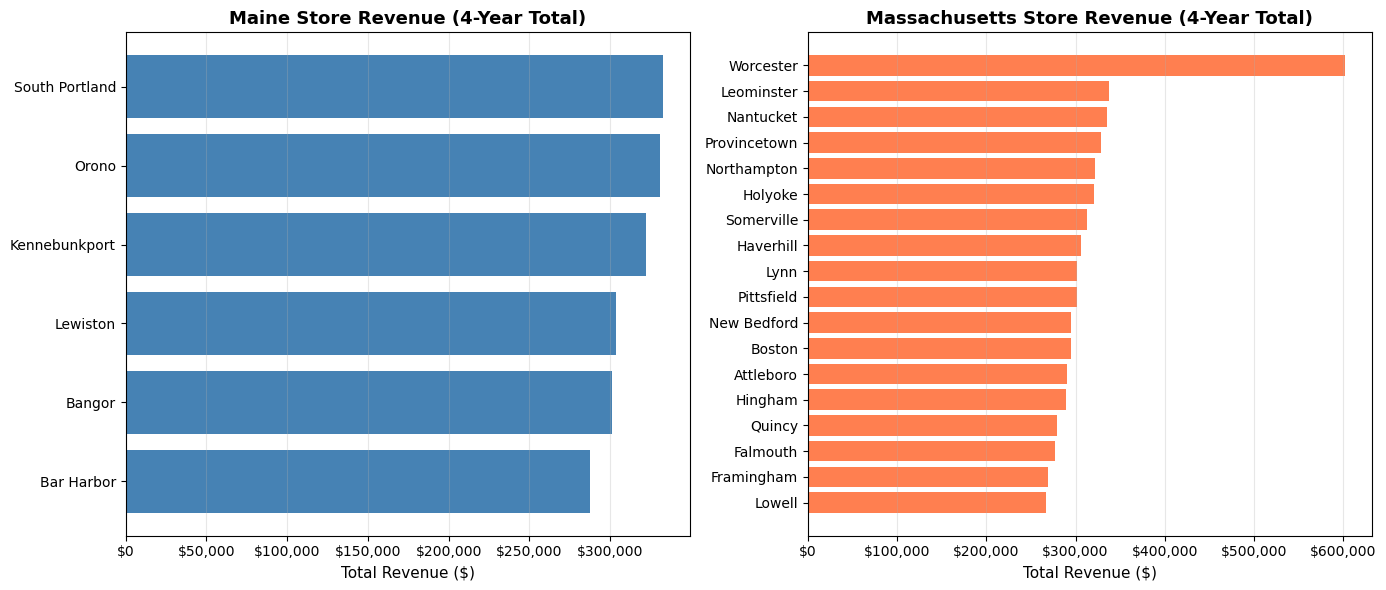

In [129]:
# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Maine stores chart
maine_stores = store_ranking[store_ranking['State'] == 'Maine'].sort_values('Sale Amount')
ax1.barh(maine_stores['Store Location'], maine_stores['Sale Amount'], color='steelblue')
ax1.set_title('Maine Store Revenue (4-Year Total)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Total Revenue ($)', fontsize=11)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(True, alpha=0.3, axis='x')

# Massachusetts stores chart
mass_stores = store_ranking[store_ranking['State'] == 'Massachusetts'].sort_values('Sale Amount')
ax2.barh(mass_stores['Store Location'], mass_stores['Sale Amount'], color='coral')
ax2.set_title('Massachusetts Store Revenue (4-Year Total)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Total Revenue ($)', fontsize=11)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
